In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error


In [81]:
all_data=[]

In [82]:
data_path="C:/Users/nasser.mohamed/Desktop/prediction/TeleForecast/data/AI_data2.csv"


In [84]:
data=pd.read_csv(data_path)
data['WEEK_START']=pd.to_datetime(data['WEEK_START']).dt.date

In [85]:
data

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27,13,2022,12,52,948753.84,59307,NaN,NaN,NaN,NaN,8591742.37
1,2023-01-03,13,2023,1,1,8591742.37,509008,948753.84,59307.0,NaN,NaN,9293707.53
2,2023-01-10,13,2023,1,2,9293707.53,545412,8591742.37,509008.0,948753.84,59307.0,9308526.80
3,2023-01-17,13,2023,1,3,9308526.80,554002,9293707.53,545412.0,8591742.37,509008.0,9706838.15
4,2023-01-24,13,2023,1,4,9706838.15,560539,9308526.80,554002.0,9293707.53,545412.0,9678802.86
...,...,...,...,...,...,...,...,...,...,...,...,...
507,2025-05-06,16,2025,5,19,15702655.05,108529,19611872.05,127050.0,17876336.61,117691.0,15570153.12
508,2025-05-13,16,2025,5,20,15570153.12,103855,15702655.05,108529.0,19611872.05,127050.0,16163852.23
509,2025-05-20,16,2025,5,21,16163852.23,115439,15570153.12,103855.0,15702655.05,108529.0,17529576.56
510,2025-05-27,16,2025,5,22,17529576.56,117082,16163852.23,115439.0,15570153.12,103855.0,6226545.67


In [86]:
df = data.fillna(data.mean(numeric_only=True))

In [87]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27,13,2022,12,52,948753.84,59307,1.109305e+07,408506.202756,1.103115e+07,407601.325397,8.591742e+06
1,2023-01-03,13,2023,1,1,8591742.37,509008,9.487538e+05,59307.000000,1.103115e+07,407601.325397,9.293708e+06
2,2023-01-10,13,2023,1,2,9293707.53,545412,8.591742e+06,509008.000000,9.487538e+05,59307.000000,9.308527e+06
3,2023-01-17,13,2023,1,3,9308526.80,554002,9.293708e+06,545412.000000,8.591742e+06,509008.000000,9.706838e+06
4,2023-01-24,13,2023,1,4,9706838.15,560539,9.308527e+06,554002.000000,9.293708e+06,545412.000000,9.678803e+06
...,...,...,...,...,...,...,...,...,...,...,...,...
507,2025-05-06,16,2025,5,19,15702655.05,108529,1.961187e+07,127050.000000,1.787634e+07,117691.000000,1.557015e+07
508,2025-05-13,16,2025,5,20,15570153.12,103855,1.570266e+07,108529.000000,1.961187e+07,127050.000000,1.616385e+07
509,2025-05-20,16,2025,5,21,16163852.23,115439,1.557015e+07,103855.000000,1.570266e+07,108529.000000,1.752958e+07
510,2025-05-27,16,2025,5,22,17529576.56,117082,1.616385e+07,115439.000000,1.557015e+07,103855.000000,6.226546e+06


In [88]:
column=["TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","NEXT_WEEK_TOTAL_AMOUNT"]

In [89]:
for col in column:
    df[col] = df[col].astype(float).astype(int)

In [90]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT
0,2022-12-27,13,2022,12,52,948753,59307,11093052,408506,11031152,407601,8591742
1,2023-01-03,13,2023,1,1,8591742,509008,948753,59307,11031152,407601,9293707
2,2023-01-10,13,2023,1,2,9293707,545412,8591742,509008,948753,59307,9308526
3,2023-01-17,13,2023,1,3,9308526,554002,9293707,545412,8591742,509008,9706838
4,2023-01-24,13,2023,1,4,9706838,560539,9308526,554002,9293707,545412,9678802
...,...,...,...,...,...,...,...,...,...,...,...,...
507,2025-05-06,16,2025,5,19,15702655,108529,19611872,127050,17876336,117691,15570153
508,2025-05-13,16,2025,5,20,15570153,103855,15702655,108529,19611872,127050,16163852
509,2025-05-20,16,2025,5,21,16163852,115439,15570153,103855,15702655,108529,17529576
510,2025-05-27,16,2025,5,22,17529576,117082,16163852,115439,15570153,103855,6226545


In [91]:
df['RATIO_TOTAL_LAST_WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_WEEK_TOTAL_AMOUNT']
df['RATIO_TOTAL_LAST_2WEEK'] = df['TOTAL_AMOUNT'] / df['LAST_2WEEK_TOTAL_AMOUNT']
df['RATIO_TRANS_LAST_WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_WEEK_TRANSACTION_COUNT']
df['RATIO_TRANS_LAST_2WEEK'] = df['TRANSACTION_COUNT'] / df['LAST_2WEEK_TRANSACTION_COUNT']

In [92]:
df

,WEEK_START,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
0,2022-12-27,13,2022,12,52,948753,59307,11093052,408506,11031152,407601,8591742,0.085527,0.086007,0.145180,0.145503
1,2023-01-03,13,2023,1,1,8591742,509008,948753,59307,11031152,407601,9293707,9.055826,0.778862,8.582596,1.248790
2,2023-01-10,13,2023,1,2,9293707,545412,8591742,509008,948753,59307,9308526,1.081702,9.795708,1.071520,9.196419
3,2023-01-17,13,2023,1,3,9308526,554002,9293707,545412,8591742,509008,9706838,1.001595,1.083427,1.015750,1.088395
4,2023-01-24,13,2023,1,4,9706838,560539,9308526,554002,9293707,545412,9678802,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
507,2025-05-06,16,2025,5,19,15702655,108529,19611872,127050,17876336,117691,15570153,0.800671,0.878405,0.854223,0.922152
508,2025-05-13,16,2025,5,20,15570153,103855,15702655,108529,19611872,127050,16163852,0.991562,0.793915,0.956933,0.817434
509,2025-05-20,16,2025,5,21,16163852,115439,15570153,103855,15702655,108529,17529576,1.038131,1.029371,1.111540,1.063670
510,2025-05-27,16,2025,5,22,17529576,117082,16163852,115439,15570153,103855,6226545,1.084492,1.125845,1.014233,1.127360


In [93]:
df.set_index('WEEK_START', inplace=True)

In [94]:
df[df['MAIN_BILLER_ID']==13]

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,11093052,408506,11031152,407601,8591742,0.085527,0.086007,0.145180,0.145503
2023-01-03,13,2023,1,1,8591742,509008,948753,59307,11031152,407601,9293707,9.055826,0.778862,8.582596,1.248790
2023-01-10,13,2023,1,2,9293707,545412,8591742,509008,948753,59307,9308526,1.081702,9.795708,1.071520,9.196419
2023-01-17,13,2023,1,3,9308526,554002,9293707,545412,8591742,509008,9706838,1.001595,1.083427,1.015750,1.088395
2023-01-24,13,2023,1,4,9706838,560539,9308526,554002,9293707,545412,9678802,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06,13,2025,5,19,24106173,742925,26168053,773146,23903297,741721,23903262,0.921206,1.008487,0.960912,1.001623
2025-05-13,13,2025,5,20,23903262,736450,24106173,742925,26168053,773146,24094654,0.991583,0.913452,0.991284,0.952537
2025-05-20,13,2025,5,21,24094654,737747,23903262,736450,24106173,742925,25321501,1.008007,0.999522,1.001761,0.993030


In [105]:
df.index = pd.to_datetime(df.index)

In [106]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,11093052,408506,11031152,407601,8591742,0.085527,0.086007,0.145180,0.145503
2023-01-03,13,2023,1,1,8591742,509008,948753,59307,11031152,407601,9293707,9.055826,0.778862,8.582596,1.248790
2023-01-10,13,2023,1,2,9293707,545412,8591742,509008,948753,59307,9308526,1.081702,9.795708,1.071520,9.196419
2023-01-17,13,2023,1,3,9308526,554002,9293707,545412,8591742,509008,9706838,1.001595,1.083427,1.015750,1.088395
2023-01-24,13,2023,1,4,9706838,560539,9308526,554002,9293707,545412,9678802,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-05-06,16,2025,5,19,15702655,108529,19611872,127050,17876336,117691,15570153,0.800671,0.878405,0.854223,0.922152
2025-05-13,16,2025,5,20,15570153,103855,15702655,108529,19611872,127050,16163852,0.991562,0.793915,0.956933,0.817434
2025-05-20,16,2025,5,21,16163852,115439,15570153,103855,15702655,108529,17529576,1.038131,1.029371,1.111540,1.063670


In [120]:
split_date='2025-06-03'
df = df[df.index < split_date]

In [121]:
df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,11093052,408506,11031152,407601,8591742,0.085527,0.086007,0.145180,0.145503
2023-01-03,13,2023,1,1,8591742,509008,948753,59307,11031152,407601,9293707,9.055826,0.778862,8.582596,1.248790
2023-01-10,13,2023,1,2,9293707,545412,8591742,509008,948753,59307,9308526,1.081702,9.795708,1.071520,9.196419
2023-01-17,13,2023,1,3,9308526,554002,9293707,545412,8591742,509008,9706838,1.001595,1.083427,1.015750,1.088395
2023-01-24,13,2023,1,4,9706838,560539,9308526,554002,9293707,545412,9678802,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-29,16,2025,4,18,19611872,127050,17876336,117691,15825971,113418,15702655,1.097086,1.239221,1.079522,1.120193
2025-05-06,16,2025,5,19,15702655,108529,19611872,127050,17876336,117691,15570153,0.800671,0.878405,0.854223,0.922152
2025-05-13,16,2025,5,20,15570153,103855,15702655,108529,19611872,127050,16163852,0.991562,0.793915,0.956933,0.817434


In [122]:
all_data = df[['MAIN_BILLER_ID', 'NEXT_WEEK_TOTAL_AMOUNT']]
all_data

,MAIN_BILLER_ID,NEXT_WEEK_TOTAL_AMOUNT
WEEK_START,,
2022-12-27,13,8591742
2023-01-03,13,9293707
2023-01-10,13,9308526
2023-01-17,13,9706838
2023-01-24,13,9678802
...,...,...
2025-04-29,16,15702655
2025-05-06,16,15570153
2025-05-13,16,16163852


In [123]:
split_date='2025-05-13'
train_df = df[df.index < split_date]
test_df = df[df.index >= split_date]

In [124]:
test_df

,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,NEXT_WEEK_TOTAL_AMOUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,,
2025-05-13,13,2025,5,20,23903262,736450,24106173,742925,26168053,773146,24094654,0.991583,0.913452,0.991284,0.952537
2025-05-20,13,2025,5,21,24094654,737747,23903262,736450,24106173,742925,25321501,1.008007,0.999522,1.001761,0.993030
2025-05-27,13,2025,5,22,25321501,750389,24094654,737747,23903262,736450,10197457,1.050918,1.059332,1.017136,1.018927
2025-05-13,14,2025,5,20,10907553,407647,11580632,424643,11948048,436537,11332411,0.941879,0.912915,0.959976,0.933820
2025-05-20,14,2025,5,21,11332411,414264,10907553,407647,11580632,424643,11995214,1.038951,0.978566,1.016232,0.975558
2025-05-27,14,2025,5,22,11995214,432853,11332411,414264,10907553,407647,4648650,1.058487,1.099716,1.044872,1.061833
2025-05-13,15,2025,5,20,19656769,763044,20628451,781516,20664149,782460,20033865,0.952896,0.951250,0.976364,0.975186
2025-05-20,15,2025,5,21,20033865,768108,19656769,763044,20628451,781516,20723614,1.019184,0.971176,1.006637,0.982844
2025-05-27,15,2025,5,22,20723614,789759,20033865,768108,19656769,763044,7715166,1.034429,1.054274,1.028187,1.035011


In [125]:
features=["MAIN_BILLER_ID","YEAR","MONTH","WEEK_NUMBER","TOTAL_AMOUNT","TRANSACTION_COUNT","LAST_WEEK_TOTAL_AMOUNT","LAST_WEEK_TRANSACTION_COUNT",	"LAST_2WEEK_TOTAL_AMOUNT",	"LAST_2WEEK_TRANSACTION_COUNT","RATIO_TOTAL_LAST_WEEK","RATIO_TOTAL_LAST_2WEEK","RATIO_TRANS_LAST_WEEK","RATIO_TRANS_LAST_2WEEK"]
pred="NEXT_WEEK_TOTAL_AMOUNT"

In [126]:
X_train = train_df[features]   # features
y_train = train_df[pred]    # target

# X_test = test_df[features]
# y_test = test_df[pred]    

In [127]:
X_train


,MAIN_BILLER_ID,YEAR,MONTH,WEEK_NUMBER,TOTAL_AMOUNT,TRANSACTION_COUNT,LAST_WEEK_TOTAL_AMOUNT,LAST_WEEK_TRANSACTION_COUNT,LAST_2WEEK_TOTAL_AMOUNT,LAST_2WEEK_TRANSACTION_COUNT,RATIO_TOTAL_LAST_WEEK,RATIO_TOTAL_LAST_2WEEK,RATIO_TRANS_LAST_WEEK,RATIO_TRANS_LAST_2WEEK
WEEK_START,,,,,,,,,,,,,,
2022-12-27,13,2022,12,52,948753,59307,11093052,408506,11031152,407601,0.085527,0.086007,0.145180,0.145503
2023-01-03,13,2023,1,1,8591742,509008,948753,59307,11031152,407601,9.055826,0.778862,8.582596,1.248790
2023-01-10,13,2023,1,2,9293707,545412,8591742,509008,948753,59307,1.081702,9.795708,1.071520,9.196419
2023-01-17,13,2023,1,3,9308526,554002,9293707,545412,8591742,509008,1.001595,1.083427,1.015750,1.088395
2023-01-24,13,2023,1,4,9706838,560539,9308526,554002,9293707,545412,1.042790,1.044453,1.011800,1.027735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-08,16,2025,4,15,15630703,107803,17714663,121051,19608880,117056,0.882360,0.797124,0.890559,0.920952
2025-04-15,16,2025,4,16,15825971,113418,15630703,107803,17714663,121051,1.012493,0.893383,1.052086,0.936944
2025-04-22,16,2025,4,17,17876336,117691,15825971,113418,15630703,107803,1.129557,1.143668,1.037675,1.091723


## model

In [128]:
model =XGBRegressor(
    objective='reg:squarederror',  # regression objective
    n_estimators=2000,              # number of trees
    learning_rate=0.1,             # step size shrinkage
    max_depth=8,                   # maximum tree depth
    subsample=0.8,                 # % of data used per tree
    colsample_bytree=0.8,          # % of features used per tree
    reg_alpha=0.1,                 # L1 regularization term
    reg_lambda=1,                  # L2 regularization term
    random_state=42                # for reproducibility
)

# Fit the model
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=None, num_parallel_tree=None, ...)

[13] lengths - X_test: 3, y_true: 3, y_pred: 3
[13] MSE: 72475804301700.67

Result Table for Product 13:

      Date   Actual  Predicted
2025-05-13 24094654 25711360.0
2025-05-20 25321501 24940680.0
2025-05-27 10197457 24849032.0


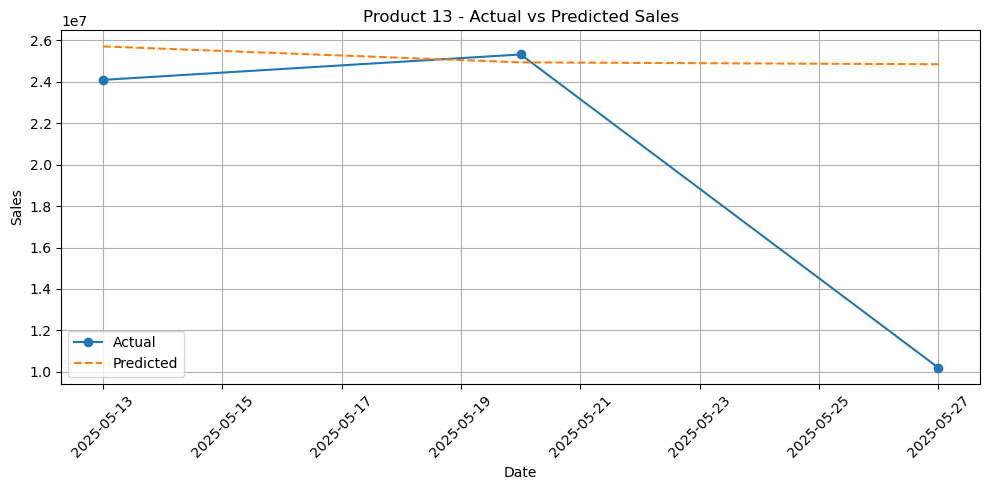

[14] lengths - X_test: 3, y_true: 3, y_pred: 3
[14] MSE: 15651622913702.33

Result Table for Product 14:

      Date   Actual  Predicted
2025-05-13 11332411 11196002.0
2025-05-20 11995214 11722265.0
2025-05-27  4648650 11494215.0


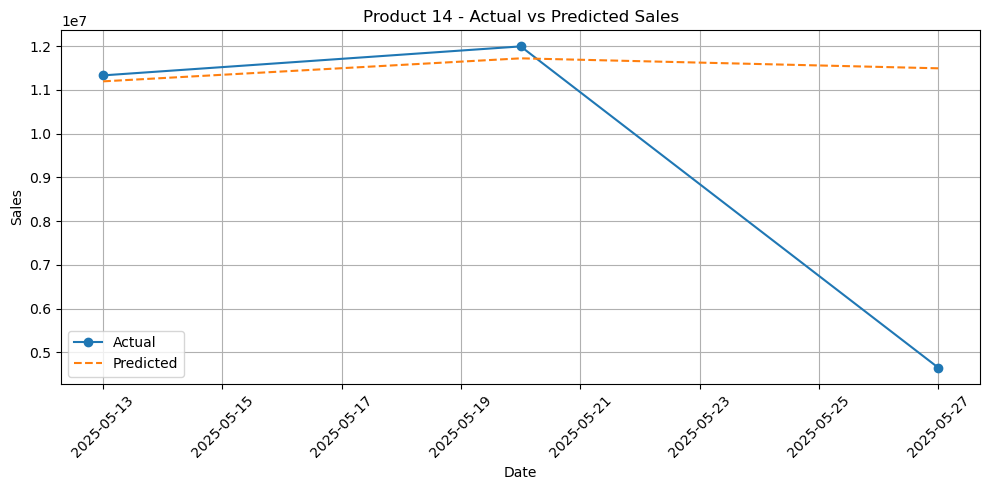

[15] lengths - X_test: 3, y_true: 3, y_pred: 3
[15] MSE: 51816877859731.00

Result Table for Product 15:

      Date   Actual  Predicted
2025-05-13 20033865 19412720.0
2025-05-20 20723614 19340412.0
2025-05-27  7715166 20090608.0


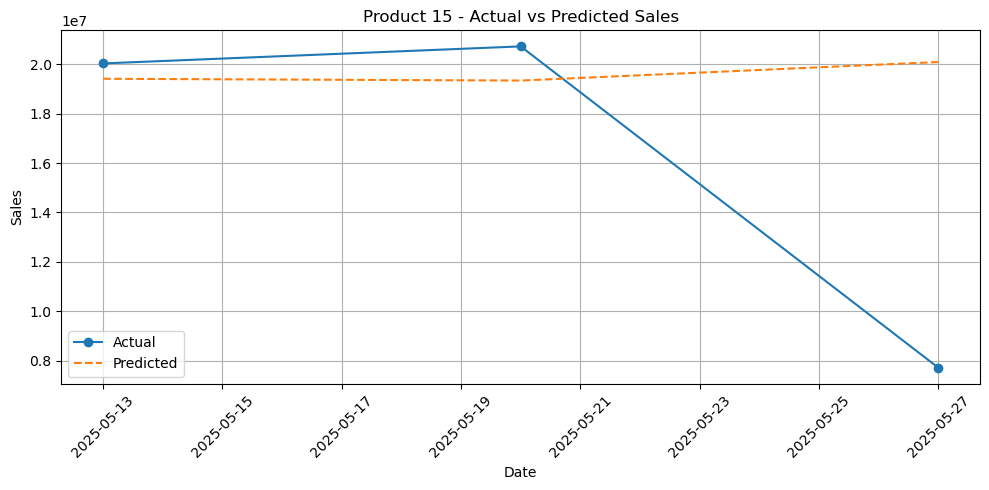

[16] lengths - X_test: 3, y_true: 3, y_pred: 3
[16] MSE: 49815223829693.66

Result Table for Product 16:

      Date   Actual  Predicted
2025-05-13 16163852 18002466.0
2025-05-20 17529576 18325418.0
2025-05-27  6226545 18286056.0


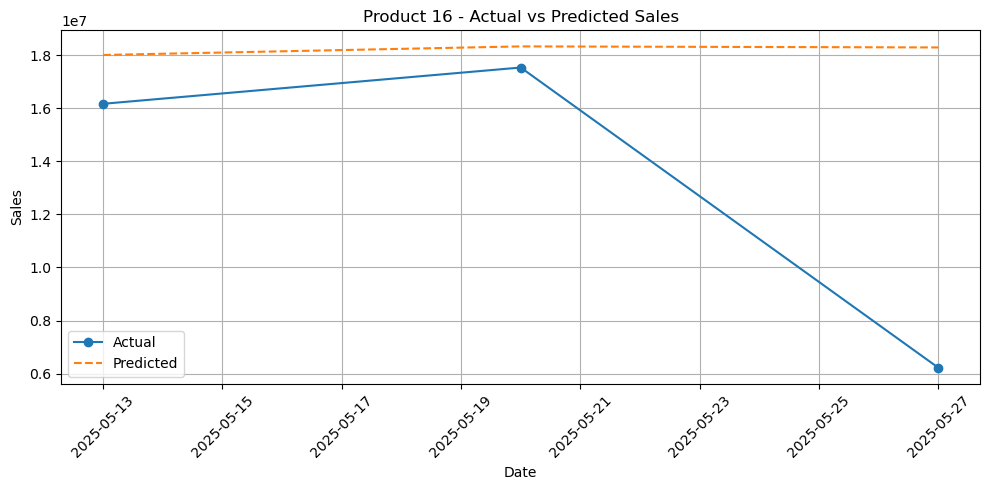

In [129]:
all_actuals = []
all_preds = []

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    # Sort by date (index) and drop rows with NaNs in features or target
    # group = group.sort_index()
    # group = group.dropna(subset=features + [pred])  # ensure no missing values

    # Prepare feature matrix and true target values
    X_test = group[features]
    y_test = group[pred]

    # Predict using the global model
    y_pred = model.predict(X_test).flatten()
    y_true = y_test.values.flatten()

    all_actuals.extend(y_true)
    all_preds.extend(y_pred)

    # Check lengths (debug)
    print(f"[{product}] lengths - X_test: {len(X_test)}, y_true: {len(y_true)}, y_pred: {len(y_pred)}")

    # Calculate MSE for this product
    mse = mean_squared_error(y_true, y_pred)
    print(f"[{product}] MSE: {mse:.2f}")

    # Create and display a table of Date, Actual, Predicted
    result_df = pd.DataFrame({
        'Date': group.index,
        'Actual': y_true,
        'Predicted': y_pred
    })
    print(f"\nResult Table for Product {product}:\n")
    print(result_df.to_string(index=False))  # Display without DataFrame index

    # Plot actual vs predicted sales over time for this product
    plt.figure(figsize=(10, 5))
    plt.plot(group.index, y_true, label='Actual', marker='o')
    plt.plot(group.index, y_pred, label='Predicted', linestyle='--')
    plt.title(f"Product {product} - Actual vs Predicted Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

[13] lengths - X_test: 3, y_true: 3, y_pred: 3
[13] MSE: 72475804301700.67

Result Table for Product 13:

WEEK_START  MAIN_BILLER_ID   Actual  Predicted
2025-05-13              13 24094654 25711360.0
2025-05-20              13 25321501 24940680.0
2025-05-27              13 10197457 24849032.0


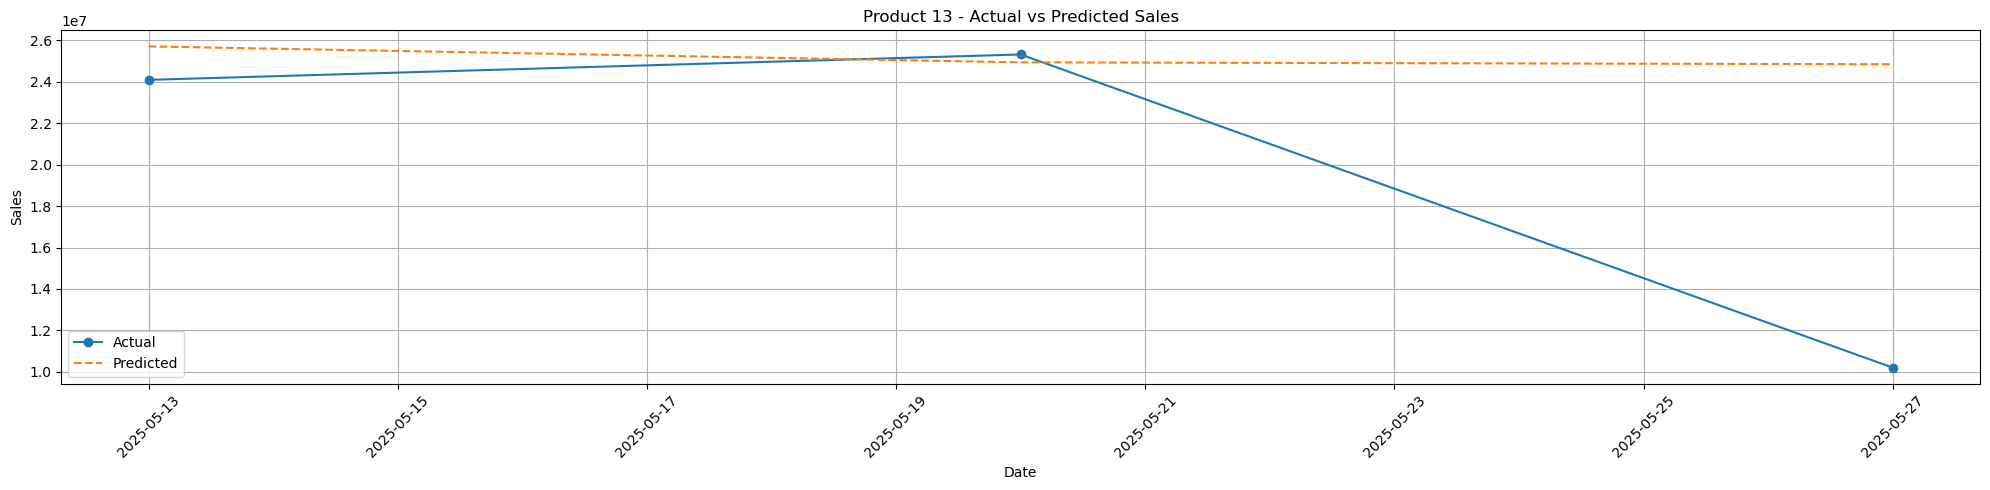

[14] lengths - X_test: 3, y_true: 3, y_pred: 3
[14] MSE: 15651622913702.33

Result Table for Product 14:

WEEK_START  MAIN_BILLER_ID   Actual  Predicted
2025-05-13              14 11332411 11196002.0
2025-05-20              14 11995214 11722265.0
2025-05-27              14  4648650 11494215.0


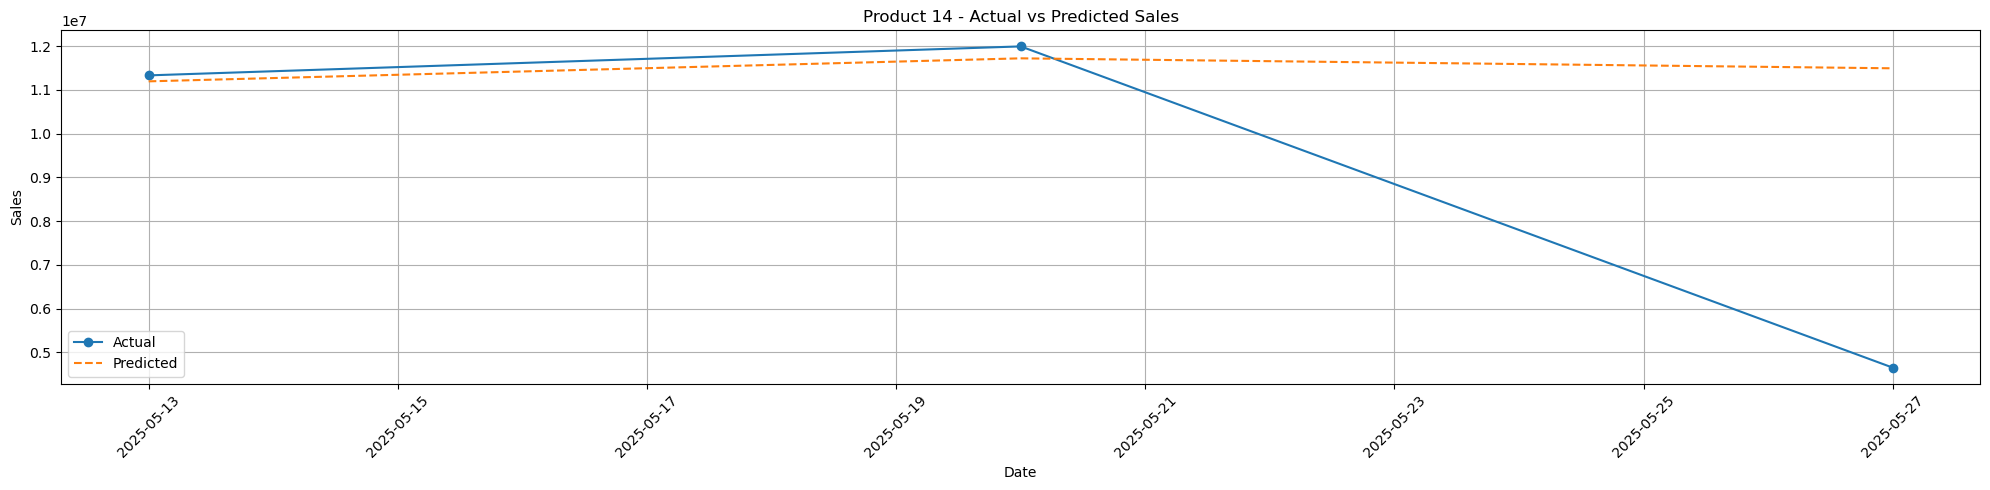

[15] lengths - X_test: 3, y_true: 3, y_pred: 3
[15] MSE: 51816877859731.00

Result Table for Product 15:

WEEK_START  MAIN_BILLER_ID   Actual  Predicted
2025-05-13              15 20033865 19412720.0
2025-05-20              15 20723614 19340412.0
2025-05-27              15  7715166 20090608.0


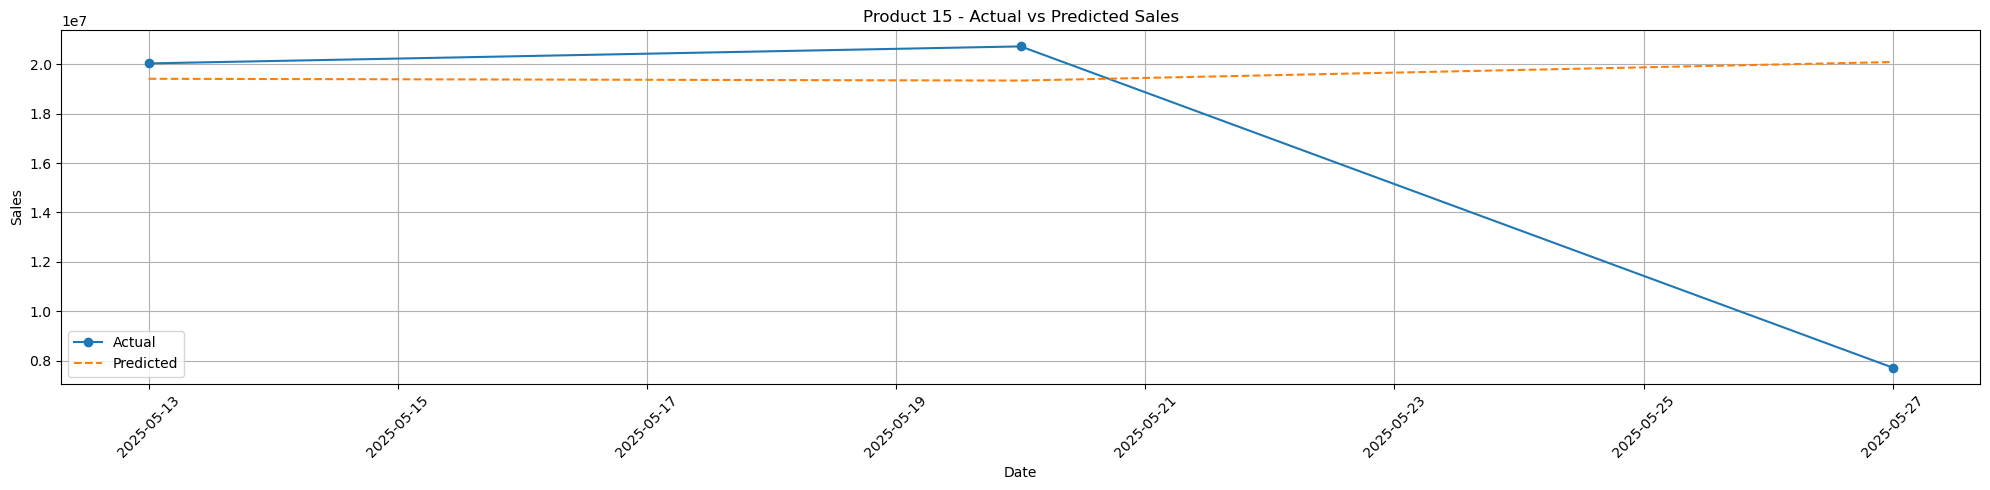

[16] lengths - X_test: 3, y_true: 3, y_pred: 3
[16] MSE: 49815223829693.66

Result Table for Product 16:

WEEK_START  MAIN_BILLER_ID   Actual  Predicted
2025-05-13              16 16163852 18002466.0
2025-05-20              16 17529576 18325418.0
2025-05-27              16  6226545 18286056.0


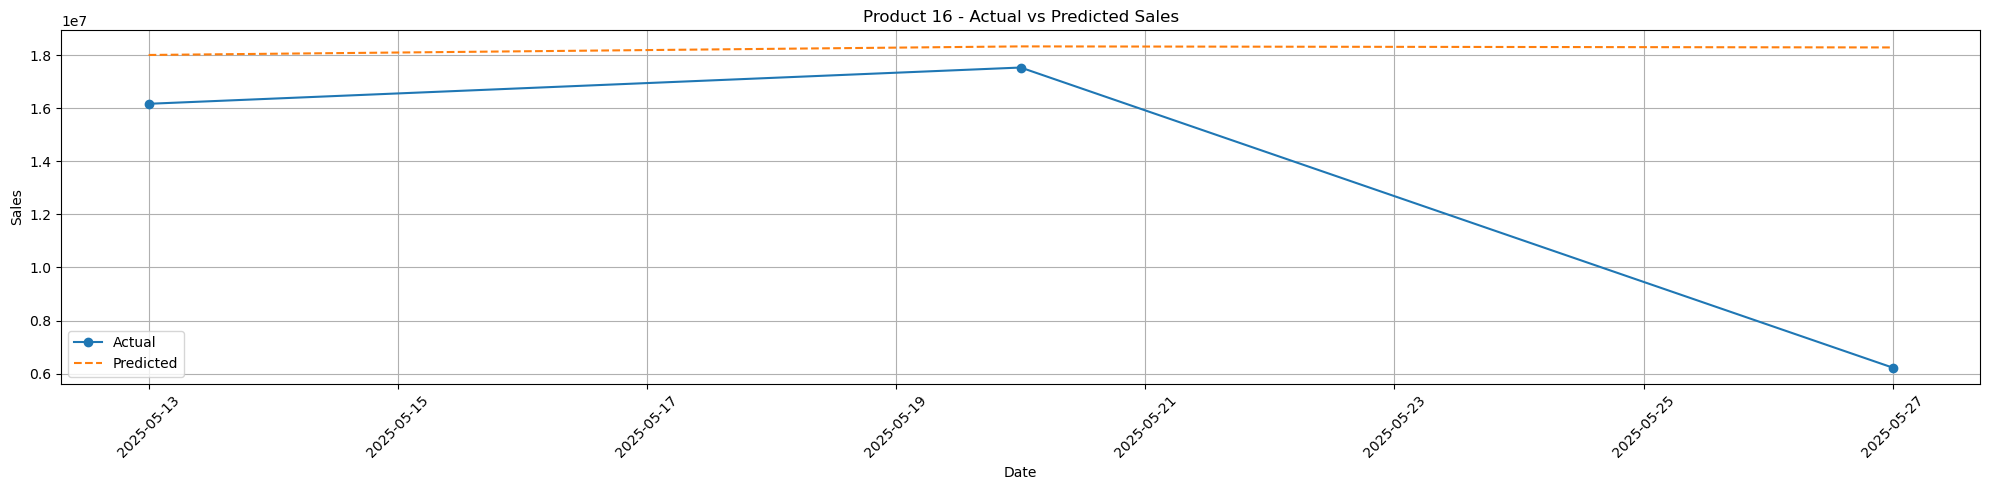


Merged DataFrame with Predictions:

    WEEK_START  MAIN_BILLER_ID  NEXT_WEEK_TOTAL_AMOUNT   Predicted
0   2022-12-27              13                 8591742         NaN
1   2023-01-03              13                 9293707         NaN
2   2023-01-10              13                 9308526         NaN
3   2023-01-17              13                 9706838         NaN
4   2023-01-24              13                 9678802         NaN
..         ...             ...                     ...         ...
503 2025-04-29              16                15702655         NaN
504 2025-05-06              16                15570153         NaN
505 2025-05-13              16                16163852  18002466.0
506 2025-05-20              16                17529576  18325418.0
507 2025-05-27              16                 6226545  18286056.0

[508 rows x 4 columns]


In [130]:
all_actuals = []
all_preds = []

# Store predictions for merging later
predictions_list = []

for product, group in test_df.groupby('MAIN_BILLER_ID'):
    # Prepare feature matrix and true target values
    X_test = group[features]
    y_test = group[pred]

    # Predict using the global model
    y_pred = model.predict(X_test).flatten()
    y_true = y_test.values.flatten()

    all_actuals.extend(y_true)
    all_preds.extend(y_pred)

    # Debug lengths
    print(f"[{product}] lengths - X_test: {len(X_test)}, y_true: {len(y_true)}, y_pred: {len(y_pred)}")

    # MSE per product
    mse = mean_squared_error(y_true, y_pred)
    print(f"[{product}] MSE: {mse:.2f}")

    # Store predictions with identifiers
    result_df = pd.DataFrame({
        'WEEK_START': group.index,  # assuming index is WEEK_START
        'MAIN_BILLER_ID': product,
        'Actual': y_true,
        'Predicted': y_pred
    })
    predictions_list.append(result_df[['WEEK_START', 'MAIN_BILLER_ID', 'Predicted']])

    # Print result table
    print(f"\nResult Table for Product {product}:\n")
    print(result_df.to_string(index=False))

    # Plot
    plt.figure(figsize=(20, 5))
    plt.plot(group.index, y_true, label='Actual', marker='o')
    plt.plot(group.index, y_pred, label='Predicted', linestyle='--')
    plt.title(f"Product {product} - Actual vs Predicted Sales")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Combine all predictions into one DataFrame
predictions_df = pd.concat(predictions_list)

# Merge predictions with your original DataFrame
# Assuming your original DataFrame is called `original_df`
# and has columns ['WEEK_START', 'MAIN_BILLER_ID', 'NEXT_WEEK_TOTAL_AMOUNT']
merged_df = all_data.merge(predictions_df, on=['WEEK_START', 'MAIN_BILLER_ID'], how='left')

# Show the merged result
print("\nMerged DataFrame with Predictions:\n")
print(merged_df)


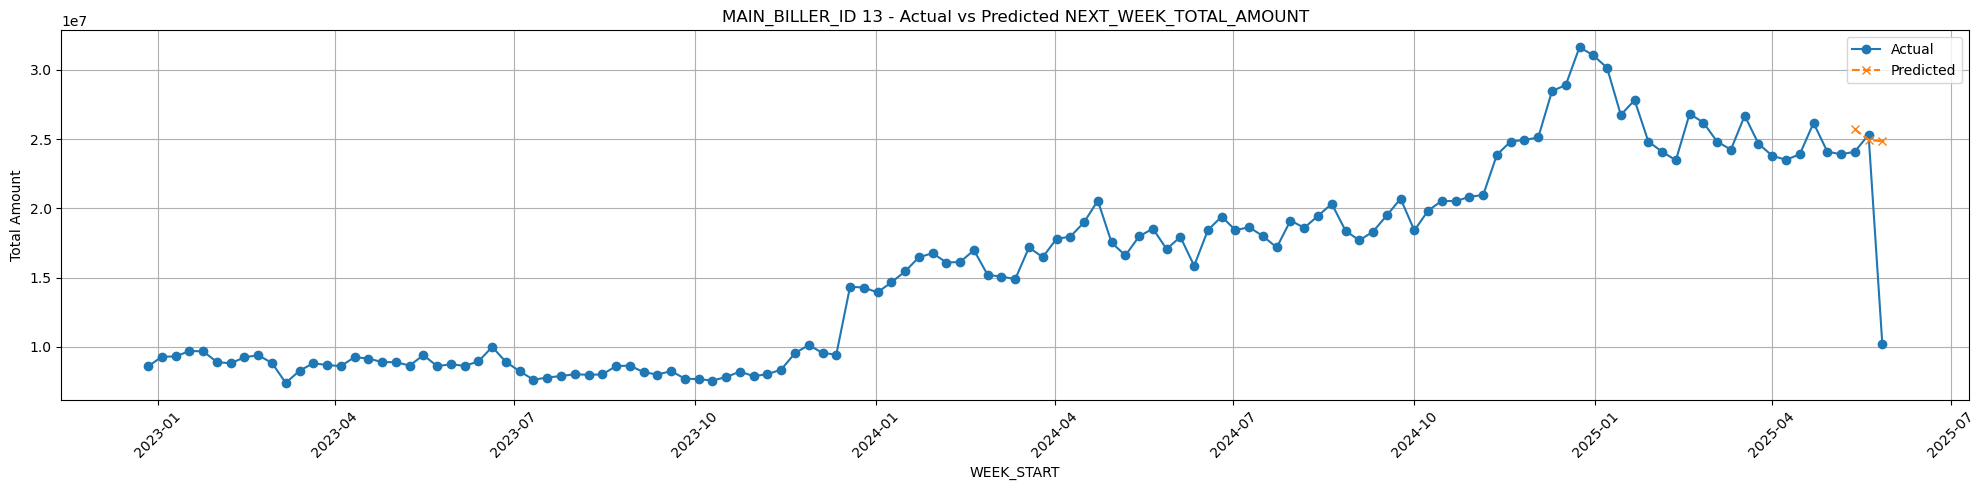

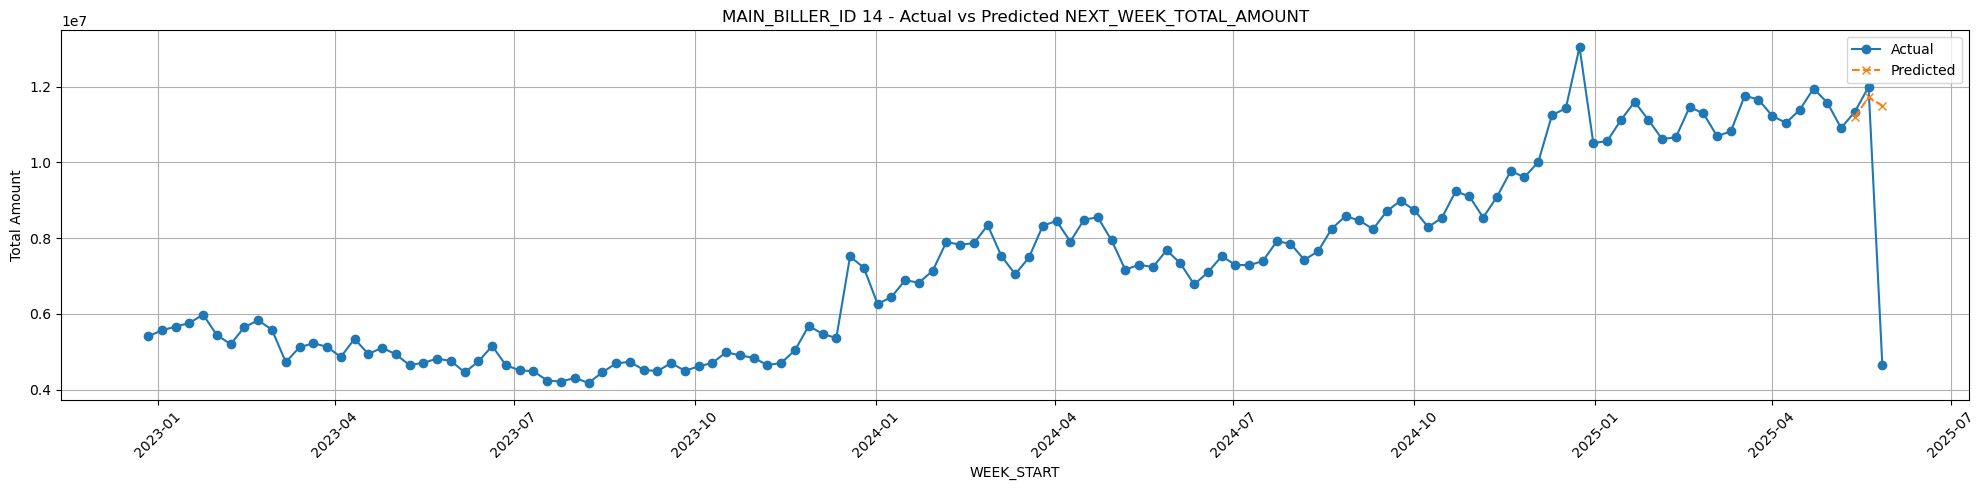

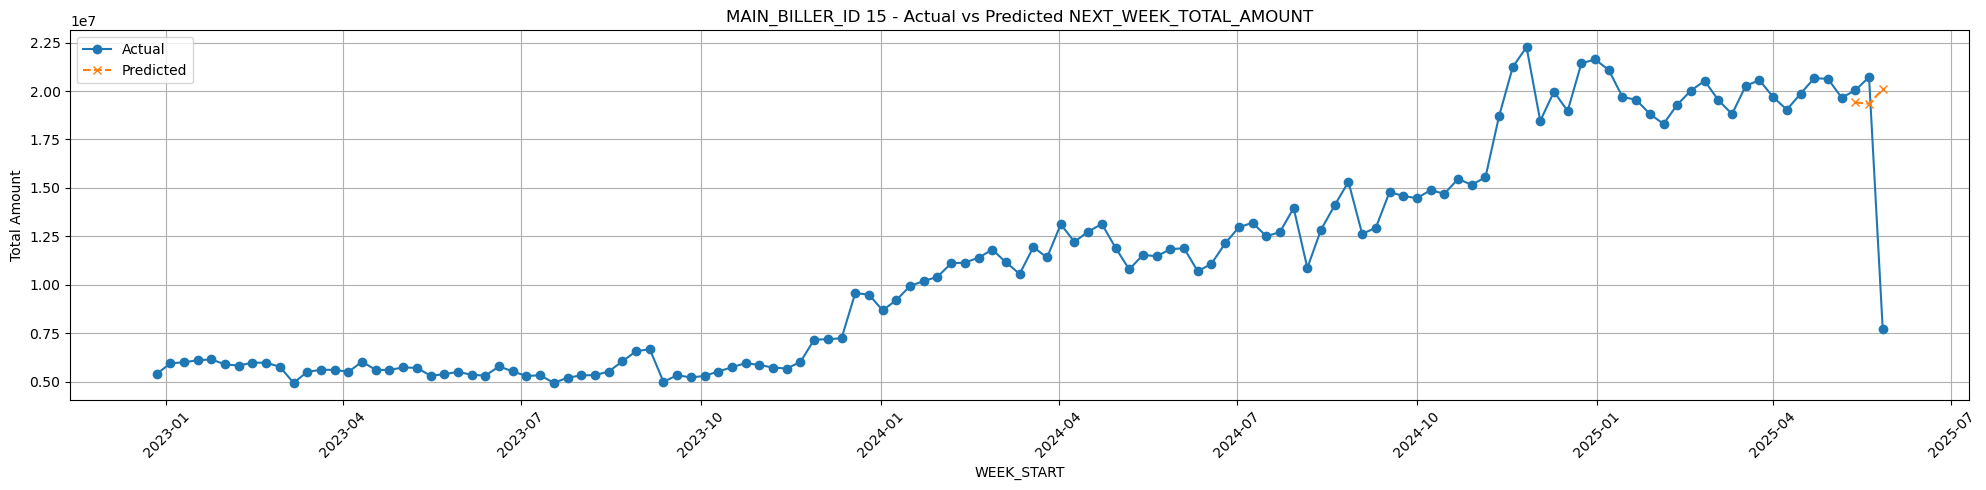

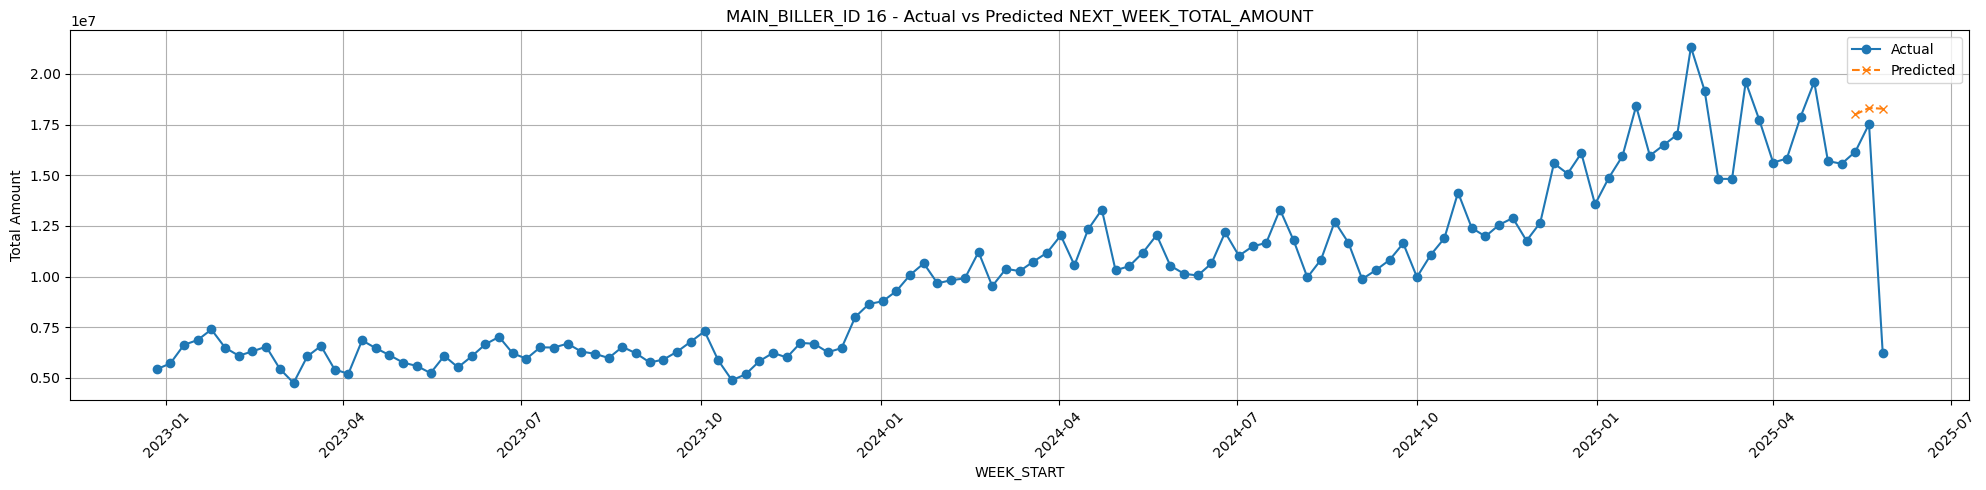

In [131]:
# Plot Actual vs Predicted for each MAIN_BILLER_ID
for product_id, group in merged_df.groupby('MAIN_BILLER_ID'):
    plt.figure(figsize=(20, 5))
    
    plt.plot(group['WEEK_START'], group['NEXT_WEEK_TOTAL_AMOUNT'], label='Actual', marker='o')
    plt.plot(group['WEEK_START'], group['Predicted'], label='Predicted', linestyle='--', marker='x')
    
    plt.title(f'MAIN_BILLER_ID {product_id} - Actual vs Predicted NEXT_WEEK_TOTAL_AMOUNT')
    plt.xlabel('WEEK_START')
    plt.ylabel('Total Amount')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()